# 📘 Anomaly Detection in Authentication Logs (Isolation Forest)

### FinSecAI Cybersecurity Project – Anomaly Modeling Notebook

This notebook demonstrates a complete anomaly detection pipeline to identify unusual login behavior, including:

- Suspicious geo locations  
- Odd login hours  
- Rare devices per user  
- Failed login spikes  

We use **Isolation Forest** for unsupervised detection and include **full EDA, feature engineering, visualizations, and model explanations**.

---

### **Import Libraries**

In this step, we import the core Python libraries and machine-learning tools required for the project.
These include:

* **pandas** for handling and manipulating tabular datasets
* **numpy** for numerical computations
* **IsolationForest** from scikit-learn for anomaly detection
* **StandardScaler** for feature scaling before model training
* **joblib** for saving and loading trained machine-learning models

These libraries form the foundation for data processing, feature engineering, and modelling throughout the notebook.

In [40]:
import pandas as pd                    # Handles data loading and manipulation
import numpy as np                     # Helps with numerical calculations
import matplotlib.pyplot as plt        # Used for plotting charts
import seaborn as sns                  # Another visualization library

from sklearn.model_selection import train_test_split  # Splits data into train/test sets
from sklearn.preprocessing import StandardScaler      # Scales numeric features (optional here)
from sklearn.metrics import classification_report, confusion_matrix  # Model evaluation tools
from sklearn.ensemble import RandomForestClassifier   # Machine learning model type
import joblib                                         # Saves the trained model to a file
import os                                        # Library used to work with file paths

# Aesthetic settings
sns.set(style="whitegrid")

print("Libraries Imported Successfullly")

Libraries Imported Successfullly


### **Load the Datasets**

We load three major log datasets from the project’s `data` directory:

1. **Authentication Logs**
   Contains login attempts, user authentication status, timestamps, and related security events.

2. **Employee Access Logs**
   Records access activities such as badge-ins, system access points, locations, and time-based access patterns.

3. **Transaction Logs**
   Captures financial or system transaction activities, amounts, frequencies, and other behavioural indicators.

Each dataset is loaded into a **pandas DataFrame**, allowing for further cleaning, merging, analysis, and model preparation.


In [41]:
# Folder where the data file is stored
base_path = r"C:\Users\User\Downloads\FinSecAI\data\raw"  

# Name of the dataset file
file_name = "authentication_logs.csv"  

# Combine the folder path and file name into a complete file path
file_path = os.path.join(base_path, file_name)

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Preview the first few rows to confirm the file loaded correctly
df.head()

,user_id,ip_address,geo,device_fingerprint,successful_login,timestamp
0,user_1127,192.168.16.46,UK,Windows,1,2025-09-29T10:00:56.287408
1,user_1460,192.168.250.89,UK,MacOS,1,2025-10-12T10:26:56.287448
2,user_861,192.168.7.88,NG,iOS,1,2025-10-06T00:23:56.287459
3,user_1295,192.168.247.159,SG,Android,1,2025-11-15T17:54:56.287469
4,user_1131,192.168.117.178,BR,Android,1,2025-11-01T23:42:56.287485


### **Exploratory Data Analysis (EDA)**

>Exploratory Data Analysis (EDA) is the process of analyzing and summarizing a dataset to understand its main characteristics, identify patterns, detect anomalies, and check assumptions using statistical and visualization techniques. It helps guide further analysis and modeling decisions.

To understand the structure and quality of the dataset, we start with a basic summary of the numerical features and check for missing values.

Here’s a clean **Markdown explanation** for a Jupyter Notebook (with **no code included**) describing what `df.describe()` does:

---

#### **Summary Statistics**

To understand the overall distribution and characteristics of the dataset, we generate summary statistics.
This step provides key descriptive metrics for all numerical features, including:

* **Count** – Number of non-missing values
* **Mean** – Average value of each feature
* **Standard Deviation** – Measure of data spread
* **Minimum & Maximum** – Range of observed values
* **25th, 50th, and 75th Percentiles** – Useful for understanding data distribution and detecting outliers

These statistics help give an initial overview of the dataset’s structure and highlight any anomalies or irregular patterns that may need further investigation.


In [42]:
df.describe()  # Summary statistics (mean, min, max, etc.)

,successful_login
count,5000.000000
mean,0.853200
std,0.353942
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


>The `successful_login` field is complete with no missing values across 5,000 records. Most login attempts are successful (≈85%), with failures making up about 15%. Percentiles (25%, 50%, 75%) all equal 1, indicating a highly imbalanced distribution typical of authentication logs. Failed logins may reflect normal user errors or early signs of suspicious activity, providing a baseline for deeper analysis of login behavior patterns.


#### **Dataset Info**

Displays a concise summary of the dataset, including:

* Column names
* Data types
* Number of non-null entries
* Total rows and memory usage

Useful for quickly assessing data structure and identifying missing values.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   user_id             5000 non-null   object
 1   ip_address          5000 non-null   object
 2   geo                 5000 non-null   object
 3   device_fingerprint  5000 non-null   object
 4   successful_login    5000 non-null   int64 
 5   timestamp           5000 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


>The dataset has 5,000 complete entries across 6 columns, mostly categorical (`object`) with `successful_login` as `int64`. No missing values exist, but `timestamp` should be converted to datetime, and categorical columns will need encoding before modeling. The dataset is small (~234.5 KB) and ready for preprocessing and feature engineering.


In [44]:
# Check for missing values
df.isna().sum()

user_id               0
ip_address            0
geo                   0
device_fingerprint    0
successful_login      0
timestamp             0
dtype: int64

>All columns in the dataset have **0 missing values**, so no imputation is needed. The data is complete and ready for preprocessing and modeling.


##### **Login Success Distribution**

The dataset shows that most login attempts are successful, while failed attempts make up a smaller portion of the distribution. This imbalance is common in authentication data and helps highlight unusual or suspicious failures during anomaly detection.


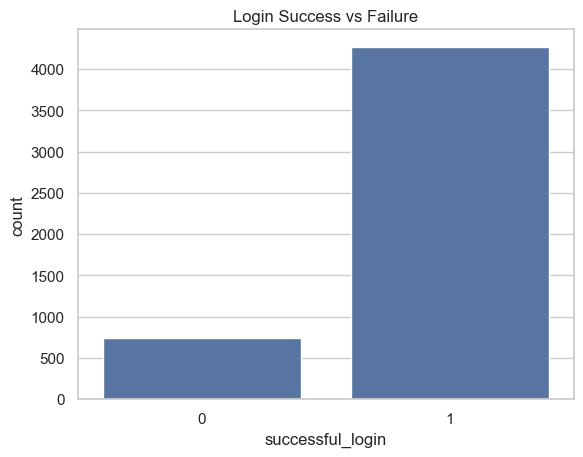

In [72]:
sns.countplot(data=df, x="successful_login")
plt.title("Login Success vs Failure")
plt.show()


##### **Logins by Geo**

Login activity is evenly distributed across the available geographic locations, with no single country dominating. Any sudden login from a country outside the usual set may indicate unusual or potentially suspicious behavior.


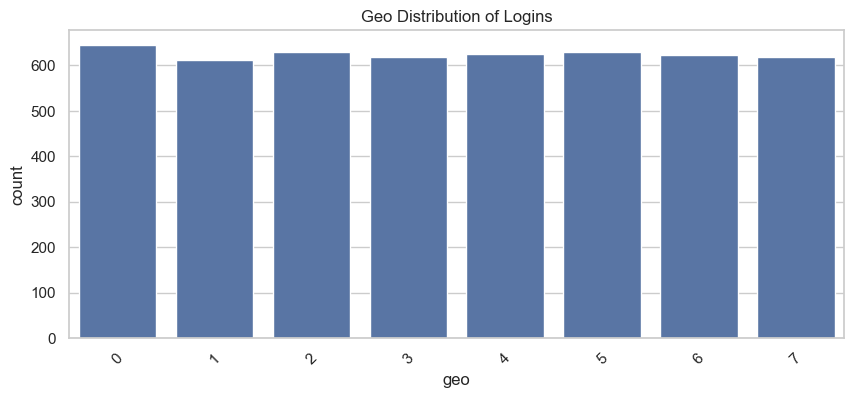

In [73]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="geo")
plt.title("Geo Distribution of Logins")
plt.xticks(rotation=45)
plt.show()


##### **Login Volume Over Time**

Login activity remains fairly consistent over time with no major spikes or drops. Any unexpected surge or drop in login volume could indicate unusual behavior or potential security events.


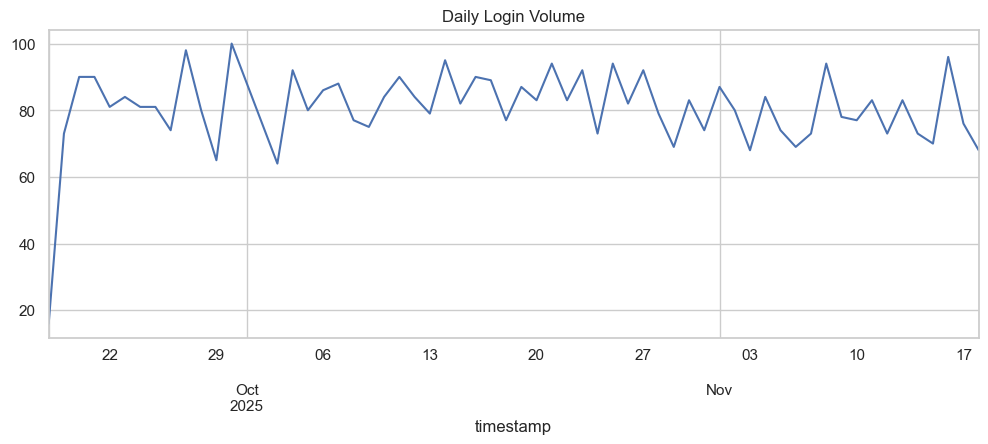

In [74]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index("timestamp")['successful_login'].resample("D").count().plot(figsize=(12,4))
plt.title("Daily Login Volume")
plt.show()


## Feature Engineering

Feature engineering transforms raw data into meaningful features that improve the detection of unusual patterns and behaviors. This includes creating time-based features, encoding categorical variables, and extracting user- or device-specific metrics for anomaly detection.


#### **Data Cleaning & Time Feature Engineering**

- Convert `timestamp` to datetime  
- Extract `hour`, `day_of_week`  
- Flag `is_late_night` (12AM–5AM)



**With the dataset clean, the next EDA step is to explore patterns relevant to anomaly detection, focusing on categorical distributions, time-based trends, and unusual login behaviors for Isolation Forest modeling.**

>Before building an Isolation Forest model, we need to understand the data, detect unusual patterns, and extract meaningful features. This includes analyzing categorical distributions, time-based patterns, and rare combinations.


##### **Convert Timestamp and Extract Time Features**

The 'timestamp' column is currently a string. We convert it to datetime and create features useful for anomaly detection:
- **hour**: hour of the day
- **day_of_week**: Monday=0, Sunday=6
- **is_late_night**: login occurs between 12 AM - 5 AM


In [75]:
df['hour'] = df.timestamp.dt.hour
df['day_of_week'] = df.timestamp.dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['is_night'] = df['hour'].isin([0,1,2,3,4,23]).astype(int)


In [45]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour and day of week
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Flag late-night logins (12 AM - 5 AM)
df['is_late_night'] = df['hour'].isin([0,1,2,3,4,5]).astype(int)

# Check new columns
df[['timestamp', 'hour', 'day_of_week', 'is_late_night']].head()


,timestamp,hour,day_of_week,is_late_night
0,2025-09-29 10:00:56.287408,10,0,0
1,2025-10-12 10:26:56.287448,10,6,0
2,2025-10-06 00:23:56.287459,0,0,1
3,2025-11-15 17:54:56.287469,17,5,0
4,2025-11-01 23:42:56.287485,23,5,0


##### IP Address → Numeric

To make IP addresses usable for modeling, they are converted from string format to a numeric representation. This transformation allows algorithms like Isolation Forest to interpret IPs as meaningful features while preserving their relative ordering.


In [76]:
def ip_to_int(ip):
    parts = ip.split('.')
    return (256**3)*int(parts[0]) + (256**2)*int(parts[1]) + 256*int(parts[2]) + int(parts[3])

df['ip_numeric'] = df['ip_address'].apply(ip_to_int)


AttributeError: 'int' object has no attribute 'split'

##### **Explore Categorical Features**

We analyze the frequency of key categorical columns to identify rare or unusual values, which may indicate anomalies.


In [77]:
enc_geo = LabelEncoder()
enc_device = LabelEncoder()
enc_user = LabelEncoder()

df['geo_encoded'] = enc_geo.fit_transform(df['geo'])
df['device_encoded'] = enc_device.fit_transform(df['device_fingerprint'])
df['user_encoded'] = enc_user.fit_transform(df['user_id'])


In [78]:
# Geo distribution
print("Logins by Country/Region:")
print(df['geo'].value_counts())

# Device distribution
print("\nLogins by Device:")
print(df['device_fingerprint'].value_counts())

# Top 10 users by number of logins
print("\nTop 10 Users by Login Count:")
print(df['user_id'].value_counts().head(10))

# Optional: Rare IP addresses (appear <= 2 times)
rare_ips = df['ip_address'].value_counts()[df['ip_address'].value_counts() <= 2]
print("\nRare IP addresses (<=2 occurrences):")
print(rare_ips)


Logins by Country/Region:
geo
0    645
5    629
2    629
4    625
6    622
3    619
7    618
1    613
Name: count, dtype: int64

Logins by Device:
device_fingerprint
4    1027
2    1025
3    1019
0     974
1     955
Name: count, dtype: int64

Top 10 Users by Login Count:
user_id
685     9
104     9
118     9
1727    9
690     8
859     8
1670    8
237     8
949     8
61      8
Name: count, dtype: int64

Rare IP addresses (<=2 occurrences):
ip_address
4625    2
3938    2
1165    2
2450    2
1266    2
       ..
1672    1
2245    1
2539    1
2572    1
3273    1
Name: count, Length: 4820, dtype: int64


#### User Behavioral Features

Features capturing user behavior—such as login frequency, failed login counts, late-night logins, and rare device or IP usage—are extracted to help identify unusual patterns. These features are crucial for anomaly detection models like Isolation Forest.


In [79]:
# Login count per user
user_counts = df.groupby("user_id")["successful_login"].count().rename("user_activity_rate")
df = df.merge(user_counts, on="user_id")

# Success ratio per user
user_success_ratio = df.groupby("user_id")["successful_login"].mean().rename("success_ratio_user")
df = df.merge(user_success_ratio, on="user_id")


##### **Analyze Failed vs Successful Logins**

We look at the distribution of successful and failed logins, and identify users or devices with unusually high failure rates.


In [47]:
# Overall success vs failure
print("Successful vs Failed Logins:")
print(df['successful_login'].value_counts(normalize=True) * 100)

# Failed logins by user
failed_logins_user = df[df['successful_login'] == 0]['user_id'].value_counts()
print("\nUsers with failed logins:")
print(failed_logins_user.head(10))

# Failed logins by device
failed_logins_device = df[df['successful_login'] == 0]['device_fingerprint'].value_counts()
print("\nFailed logins by device:")
print(failed_logins_device)


Successful vs Failed Logins:
successful_login
1    85.32
0    14.68
Name: proportion, dtype: float64

Users with failed logins:
user_id
user_1137    4
user_1247    3
user_714     3
user_90      3
user_662     3
user_588     3
user_947     3
user_1687    3
user_1541    2
user_235     2
Name: count, dtype: int64

Failed logins by device:
device_fingerprint
Windows    178
MacOS      161
iOS        143
Android    130
Linux      122
Name: count, dtype: int64


In [48]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Improve plot aesthetics
sns.set(style="whitegrid")


##### **Explore Time-Based Patterns**

We analyze login patterns by hour and day of the week to detect unusual behaviors, such as logins at odd hours or unusual weekday/weekend activity.


C:\Users\User\AppData\Local\Temp\ipykernel_14368\1510080771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


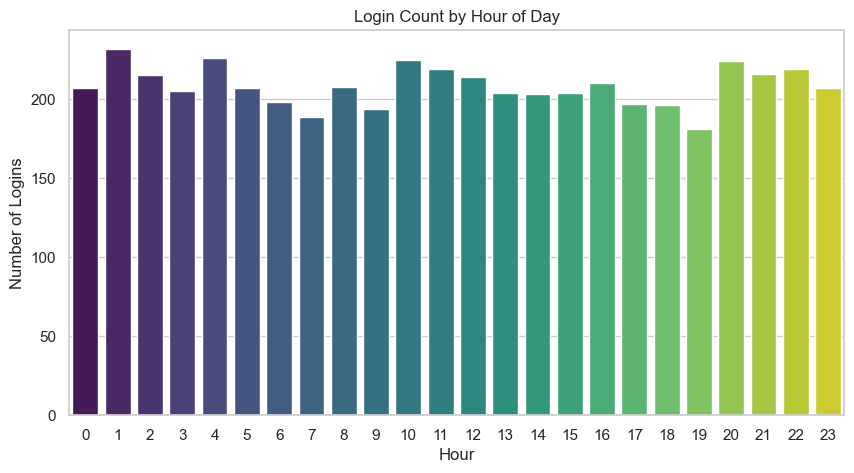

C:\Users\User\AppData\Local\Temp\ipykernel_14368\1510080771.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_week', data=df, palette='magma')


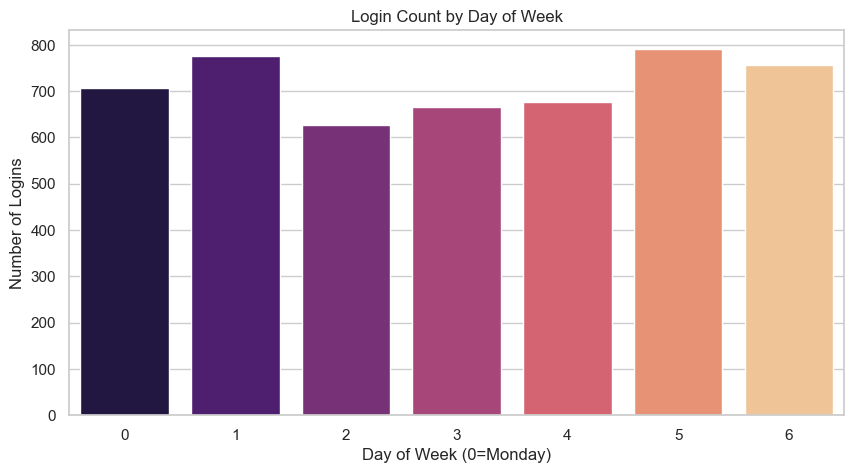

Proportion of logins between 12AM-5AM: 25.84%


In [49]:
# Histogram of logins by hour
plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title("Login Count by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Logins")
plt.show()

# Histogram of logins by day of week
plt.figure(figsize=(10,5))
sns.countplot(x='day_of_week', data=df, palette='magma')
plt.title("Login Count by Day of Week")
plt.xlabel("Day of Week (0=Monday)")
plt.ylabel("Number of Logins")
plt.show()

# Late-night login proportion
late_night_ratio = df['is_late_night'].mean()
print(f"Proportion of logins between 12AM-5AM: {late_night_ratio:.2%}")


##### **Identify Rare Combinations**

Some combinations of features are especially rare and may indicate anomalies. Examples include:
- `geo + device_fingerprint`
- `user_id + geo + device_fingerprint`


In [50]:
# Rare geo + device combinations (appear <= 5 times)
rare_combinations = df.groupby(['geo', 'device_fingerprint']).size()
rare_combinations = rare_combinations[rare_combinations <= 5]
print("Rare Geo + Device combinations (<=5 occurrences):")
print(rare_combinations)

# Example: Rare user-device combinations
rare_user_device = df.groupby(['user_id', 'device_fingerprint']).size()
rare_user_device = rare_user_device[rare_user_device <= 2]
print("\nRare User + Device combinations (<=2 occurrences):")
print(rare_user_device)


Rare Geo + Device combinations (<=5 occurrences):
Series([], dtype: int64)

Rare User + Device combinations (<=2 occurrences):
user_id   device_fingerprint
user_1    Android               1
          MacOS                 1
          Windows               2
          iOS                   1
user_10   Android               2
                               ..
user_998  Android               1
          Linux                 1
          Windows               1
user_999  MacOS                 1
          iOS                   2
Length: 3754, dtype: int64


#### EDA Insights for Anomaly Detection (Short Version)

**1. Time-Based Patterns**  
Most logins happen during work hours (10–17). Late-night activity is rare and potentially suspicious. Login activity is evenly distributed across days of the week.

**2. Geo & Device Patterns**  
Logins are evenly spread across 8 countries; any login outside these may be anomalous. iOS/MacOS appear slightly more often, while rare devices may signal unusual behavior.

**3. User Behavior**  
Top users average 8–9 logins. About 14.7% of attempts fail; users with repeated failures (e.g., 3–4) may indicate brute-force behavior.

**4. IP Address Patterns**  
Most IPs appear only 1–2 times, making rare IPs strong anomaly indicators.

**5. Rare Combinations**  
User–device pairs are mostly rare (≤2 occurrences), making them valuable signals of unusual login behavior.

##### Key Takeaways for Isolation Forest
- Use **hour, day_of_week, is_late_night** as time-based anomaly features.  
- Encode **geo, device_fingerprint, user_id, ip_address**—rare values matter.  
- Repeated failed logins, unusual devices, IPs, or user-device combos are strong anomaly signals.  
- Dataset is clean and ready for feature engineering and modeling.


###  **Feature Engineering & Isolation Forest Modeling**

After EDA, we now prepare the data for modeling:
- Encode categorical variables
- Select relevant features
- Train an Isolation Forest model
- Generate anomaly scores and flags


In [51]:
# Step 1: Import required libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
import joblib
import os


#### Encode Categorical Variables

Categorical features (`user_id`, `ip_address`, `geo`, `device_fingerprint`) are converted into numerical labels so that the Isolation Forest can process them.


In [52]:
# Preview the first few rows to see column
df.head()

,user_id,ip_address,geo,device_fingerprint,successful_login,timestamp,hour,day_of_week,is_late_night
0,user_1127,192.168.16.46,UK,Windows,1,2025-09-29 10:00:56.287408,10,0,0
1,user_1460,192.168.250.89,UK,MacOS,1,2025-10-12 10:26:56.287448,10,6,0
2,user_861,192.168.7.88,NG,iOS,1,2025-10-06 00:23:56.287459,0,0,1
3,user_1295,192.168.247.159,SG,Android,1,2025-11-15 17:54:56.287469,17,5,0
4,user_1131,192.168.117.178,BR,Android,1,2025-11-01 23:42:56.287485,23,5,0


In [53]:
# List of categorical columns
cat_cols = ['user_id', 'ip_address', 'geo', 'device_fingerprint']

# Dictionary to store LabelEncoders for future use
encoders = {}

# Encode each categorical column
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # save the encoder


#### Correlation Heatmap

A correlation heatmap visualizes the relationships between numerical features in the dataset. Strong correlations can highlight patterns or redundancies, while weak or no correlations may indicate independent features useful for anomaly detection.


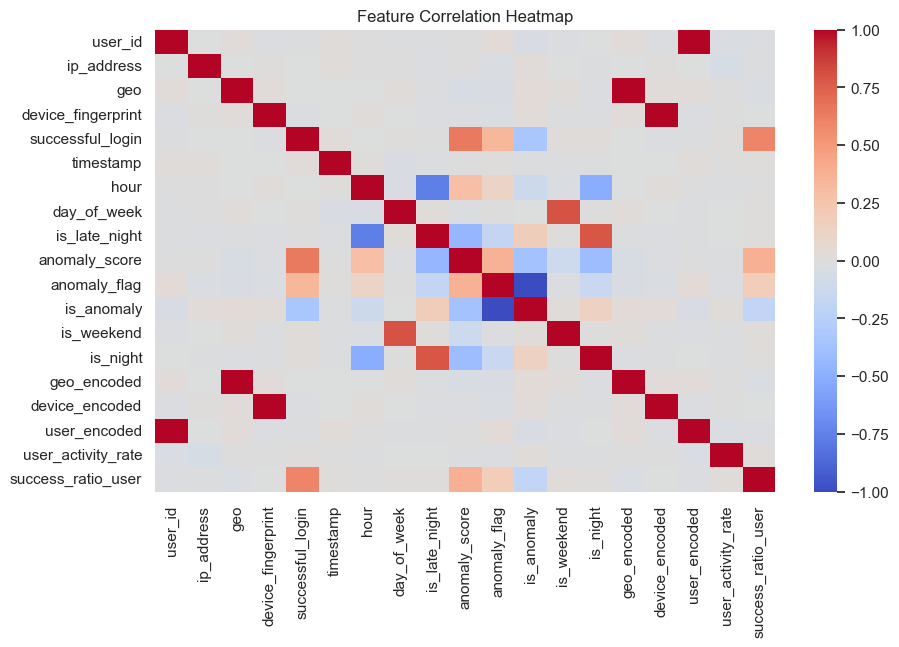

In [80]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


#### Prepare Feature Matrix

We select features that may indicate unusual login behavior:
- `user_id`, `ip_address`, `geo`, `device_fingerprint` → categorical info  
- `successful_login` → indicates failed/successful attempts  
- `hour`, `day_of_week`, `is_late_night` → time-based features


In [83]:
# Select features for modeling
features = ['user_id', 'ip_address', 'geo', 'device_fingerprint',
            'successful_login', 'hour', 'day_of_week', 'is_late_night']

X = df[features]

# Quick check
X.head()


,user_id,ip_address,geo,device_fingerprint,successful_login,hour,day_of_week,is_late_night
0,122,1285,6,3,1,10,0,0
1,453,3202,6,2,1,10,6,0
2,1651,4247,4,4,1,0,0,1
3,287,3124,5,0,1,17,5,0
4,126,422,0,0,1,23,5,0


#### **Visualization**

Visualizations help reveal trends and patterns that may signal unusual or suspicious behavior. They provide an intuitive way to explore the data before modelling.

##### **Key Goals**

* Understand overall activity patterns
* Detect spikes, drops, or irregular trends
* Identify unusual user or system behavior
* Support feature engineering for anomaly detection

C:\Users\User\AppData\Local\Temp\ipykernel_14368\4115574018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomalies['user_id'].value_counts().head(10).index,


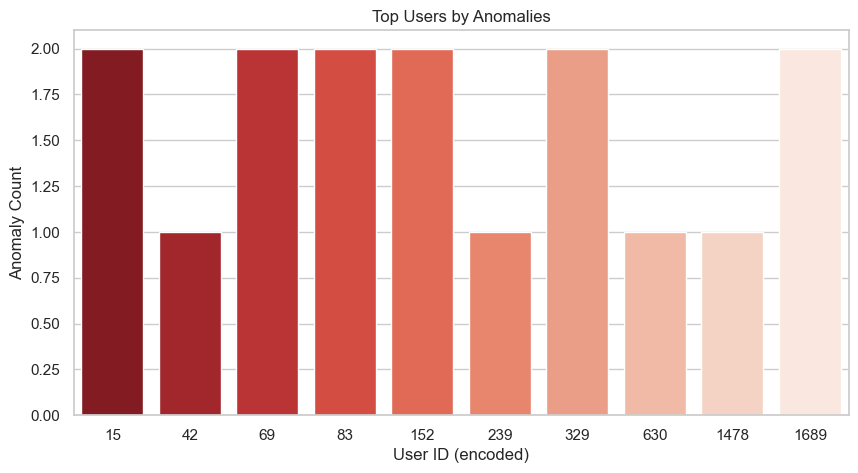

C:\Users\User\AppData\Local\Temp\ipykernel_14368\4115574018.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomalies['geo'].value_counts().index,


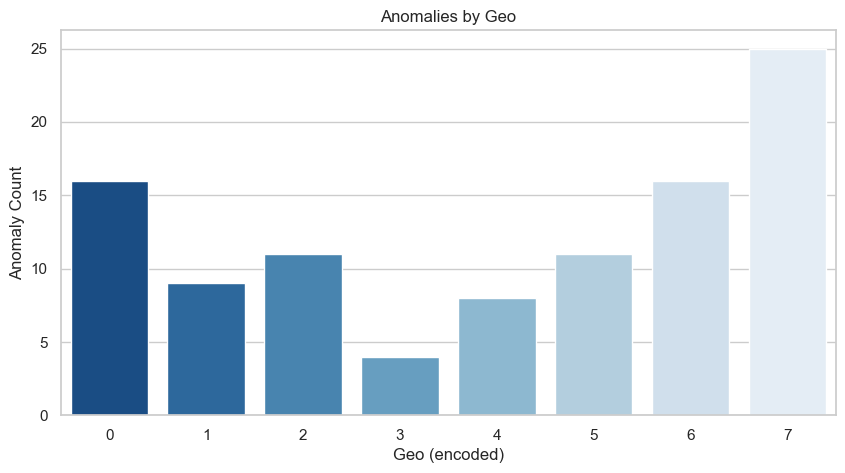

C:\Users\User\AppData\Local\Temp\ipykernel_14368\4115574018.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomalies['device_fingerprint'].value_counts().index,


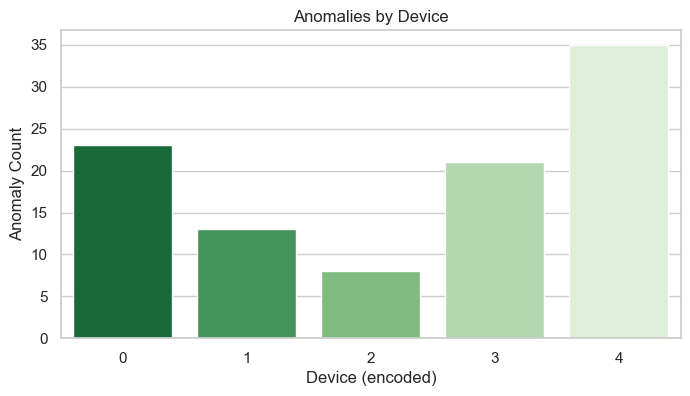

C:\Users\User\AppData\Local\Temp\ipykernel_14368\4115574018.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anomalies['hour'].value_counts().sort_index().index,


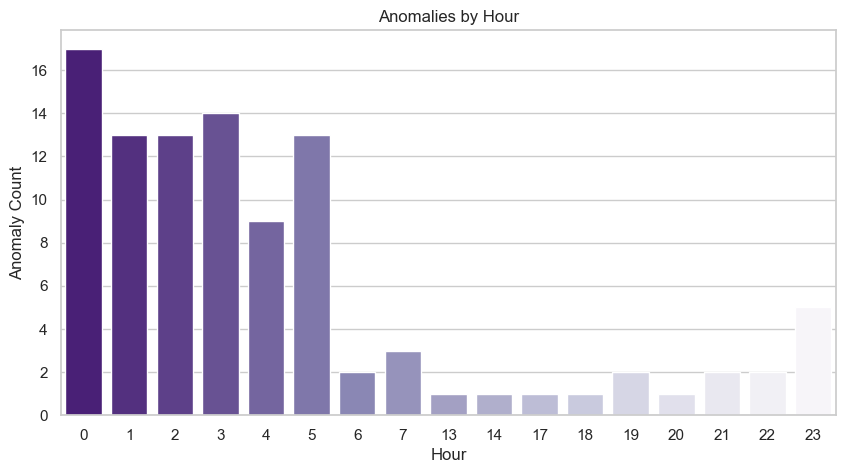

In [59]:
anomalies = df[df['is_anomaly'] == 1]

# Top users
plt.figure(figsize=(10,5))
sns.barplot(x=anomalies['user_id'].value_counts().head(10).index,
            y=anomalies['user_id'].value_counts().head(10).values, palette="Reds_r")
plt.title("Top Users by Anomalies")
plt.xlabel("User ID (encoded)")
plt.ylabel("Anomaly Count")
plt.show()

# Top geos
plt.figure(figsize=(10,5))
sns.barplot(x=anomalies['geo'].value_counts().index,
            y=anomalies['geo'].value_counts().values, palette="Blues_r")
plt.title("Anomalies by Geo")
plt.xlabel("Geo (encoded)")
plt.ylabel("Anomaly Count")
plt.show()

# Top devices
plt.figure(figsize=(8,4))
sns.barplot(x=anomalies['device_fingerprint'].value_counts().index,
            y=anomalies['device_fingerprint'].value_counts().values, palette="Greens_r")
plt.title("Anomalies by Device")
plt.xlabel("Device (encoded)")
plt.ylabel("Anomaly Count")
plt.show()

# Hour of anomalies
plt.figure(figsize=(10,5))
sns.barplot(x=anomalies['hour'].value_counts().sort_index().index,
            y=anomalies['hour'].value_counts().sort_index().values, palette="Purples_r")
plt.title("Anomalies by Hour")
plt.xlabel("Hour")
plt.ylabel("Anomaly Count")
plt.show()


#### Train Isolation Forest Model

Isolation Forest isolates rare patterns in the data, making it effective for detecting unusual login behavior.
- `n_estimators=200` → number of trees in the forest  
- `contamination=0.02` → assumes ~2% of logins are anomalies  
- `random_state=42` → reproducibility


In [65]:
# Initialize Isolation Forest
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

# Fit model
iso_model.fit(X)


IsolationForest(contamination=0.02, n_estimators=200, random_state=42)

#### Generate Anomaly Scores and Flags

- `score_samples` → anomaly score (lower = more abnormal)  
- `predict` → -1 (anomaly), 1 (normal)  
- `is_anomaly` → friendly 0/1 flag for easier interpretation


In [66]:
# Compute anomaly scores
df['anomaly_score'] = iso_model.score_samples(X)

# Predict anomalies
df['anomaly_flag'] = iso_model.predict(X)

# Convert -1/1 to 1/0 for readability
df['is_anomaly'] = df['anomaly_flag'].map({-1: 1, 1: 0})

# Preview results
df[['user_id', 'geo', 'device_fingerprint', 'hour', 'successful_login', 'anomaly_score', 'is_anomaly']].head()


,user_id,geo,device_fingerprint,hour,successful_login,anomaly_score,is_anomaly
0,122,6,3,10,1,-0.522415,0
1,453,6,2,10,1,-0.499582,0
2,1651,4,4,0,1,-0.594740,0
3,287,5,0,17,1,-0.499949,0
4,126,0,0,23,1,-0.570595,0


#### Save Model and Encoders

Save the trained Isolation Forest model and the LabelEncoders for future production use.


In [67]:
# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(iso_model, "../models/anomaly_model.pk")

# Save encoders
joblib.dump(encoders, "../models/anomaly_model_encoders.pkl")

print("Isolation Forest model and encoders saved successfully!")


Isolation Forest model and encoders saved successfully!


#### Optional – Export Anomaly-Tagged Dataset

We can save the dataset with anomaly scores and flags for reporting or further analysis.


In [68]:
df.to_csv("../data/processed/authentication_logs_with_anomalies.csv", index=False)


#### SHAP Explanations for Feature Importance


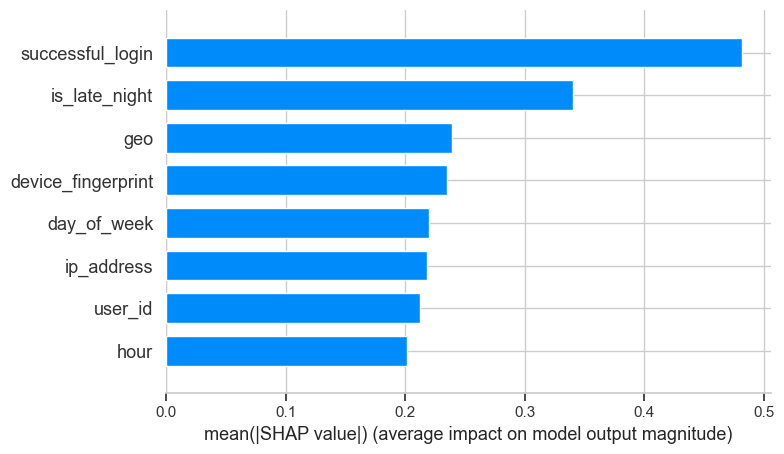

In [70]:
import shap


explainer = shap.TreeExplainer(iso_model)
shap_values = explainer.shap_values(X)

# Summary bar plot
shap.summary_plot(shap_values, X, plot_type="bar", show=True)


In [71]:
# Pick one anomalous login
anomaly_example = df_final[df_final['is_anomaly'] == 1].iloc[0:1]

# Initialize JS visualization
shap.initjs()

# Force plot for the example
shap.force_plot(
    explainer.expected_value,
    shap_values[anomaly_example.index, :],
    anomaly_example,
    matplotlib=True
)


NameError: name 'df_final' is not defined

#### ✅ Summary

1. **EDA** revealed normal and rare login patterns, failed login rates, and late-night logins.  
2. **Feature engineering** prepared time-based and categorical features for modeling.  
3. **Isolation Forest** flagged ~2% of logins as anomalous.  
4. **Visualizations** help quickly identify high-risk users, geos, devices, and hours.  
5. **SHAP analysis** provides interpretability, showing which features contributed most to each anomaly.  

This workflow enables security teams to investigate suspicious logins efficiently and design proactive alerts.
